In [74]:
import pandas as pd

df = pd.read_csv("Data/student_performance.csv")
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [75]:
features = ['study_hours_per_week', 'attendance_rate', 'final_score']
X = df[features]
X.head()

,study_hours_per_week,attendance_rate,final_score
0,25,63.8,67
1,2,54.7,28
2,10,90.5,49
3,26,66.8,70
4,25,73.0,77


In [76]:
X.describe()

,study_hours_per_week,attendance_rate,final_score
count,500.000000,500.000000,500.000000
mean,15.312000,76.380600,55.980000
std,8.568167,13.817681,15.373754
min,2.000000,50.200000,20.000000
25%,8.000000,64.475000,45.000000
50%,15.000000,76.500000,56.000000
75%,23.000000,88.525000,68.000000
max,30.000000,100.000000,95.000000


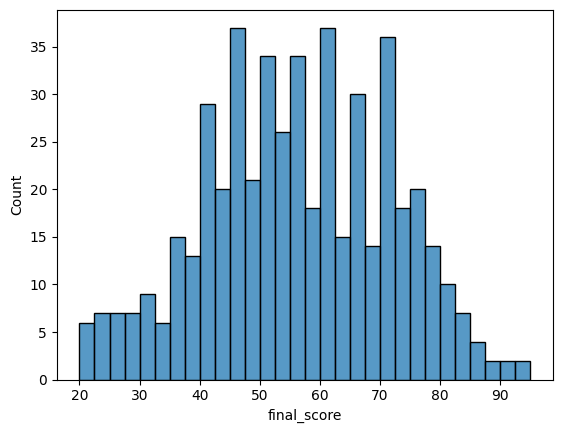

In [77]:
# data visualising
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=X['final_score'], bins=30)
plt.show()

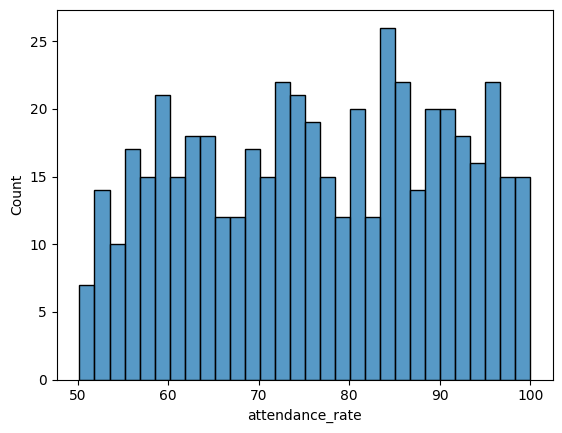

In [78]:
# data visualising

sns.histplot(data=X['attendance_rate'], bins=30)
plt.show()

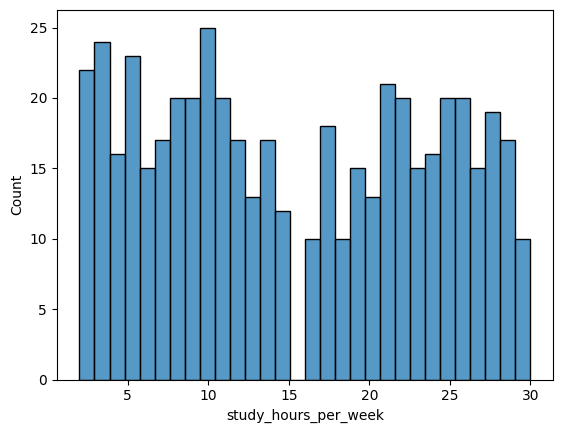

In [79]:
# data visualising
sns.histplot(data=X['study_hours_per_week'], bins=30)
plt.show()

/tmp/ipykernel_7218/3625717660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X, x='attendance_rate', palette="viridis")


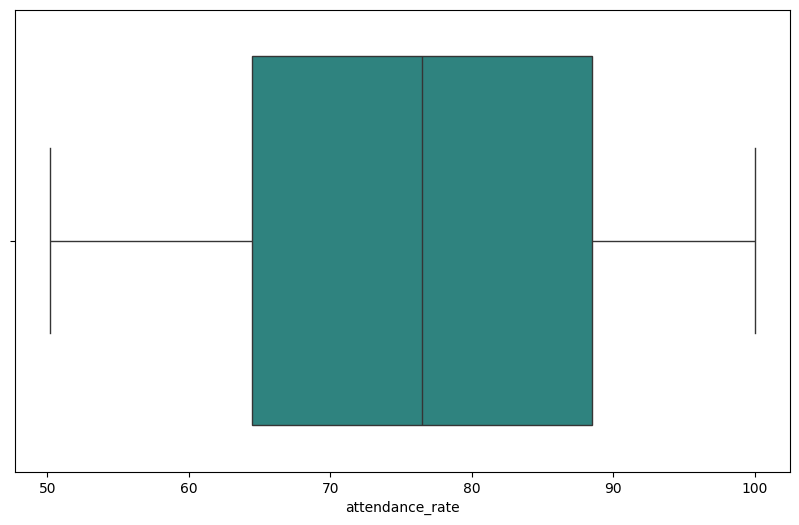

In [80]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=X, x='attendance_rate', palette="viridis")
plt.show()

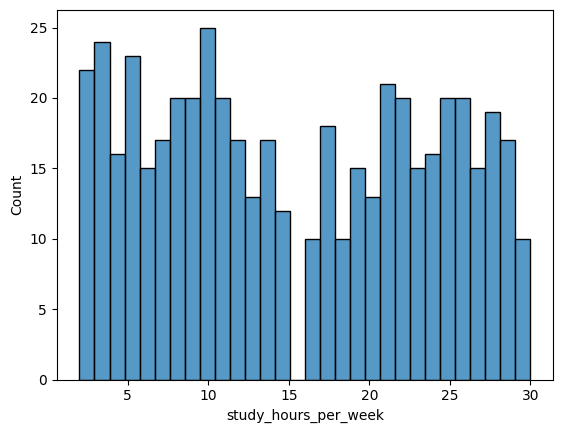

In [81]:
X["attendance_rate"].describe()
sns.histplot(data=X['study_hours_per_week'], bins=30)
plt.show()

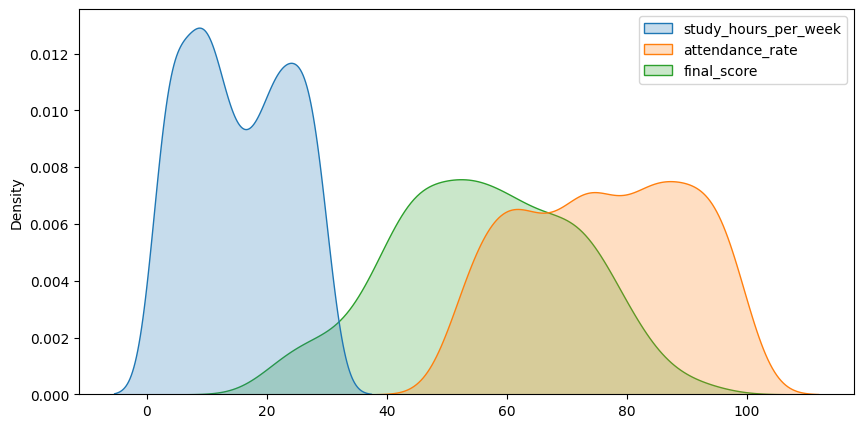

In [82]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=X,  fill=True, color='purple')
plt.show()

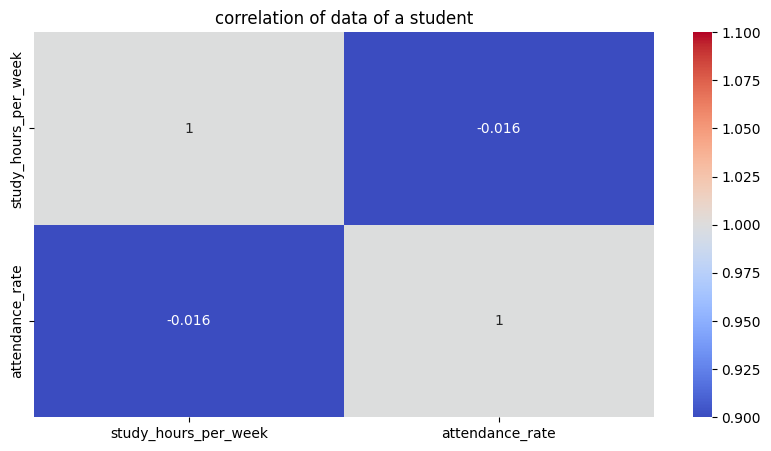

In [83]:
plt.figure(figsize=(10,5))
sns.heatmap(X[['study_hours_per_week', 'attendance_rate']].corr(), annot=True, cmap='coolwarm', vmin=1, vmax=1)
plt.title("correlation of data of a student")
plt.show()

In [84]:
X.columns

Index(['study_hours_per_week', 'attendance_rate', 'final_score'], dtype='str')

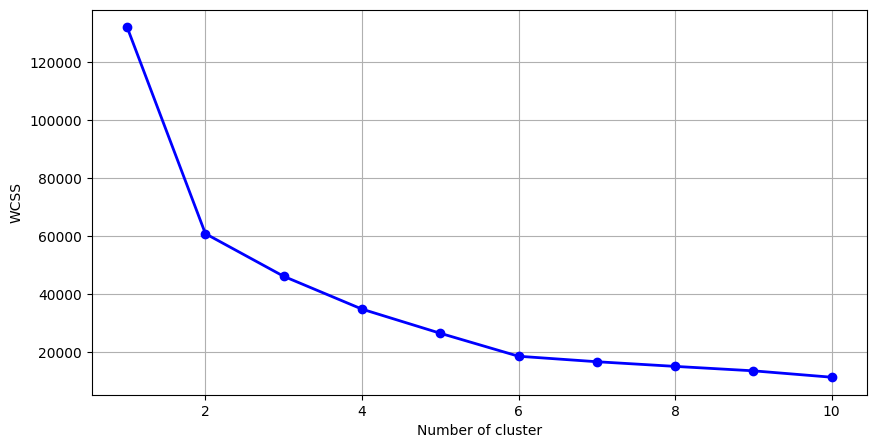

In [85]:
from sklearn.cluster import KMeans 
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    t = km.fit(X[['study_hours_per_week', 'attendance_rate']])
    wcss.append(t.inertia_)


plt.figure(figsize=(10,5))
plt.plot(range(1,11), wcss, marker='o', color='blue', linewidth=2)
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

   avg study_Hr  AVG_attendance_rate
0         22.85                61.23
1         24.65                81.23
2         13.45                93.82
3          8.36                79.02
4          7.99                60.72


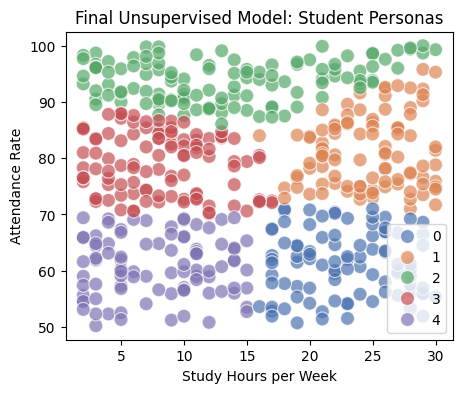

,study_hours_per_week,attendance_rate,final_score,Student_profile
0,25,63.8,67,0
1,2,54.7,28,4
2,10,90.5,49,2
3,26,66.8,70,0
4,25,73.0,77,1
...,...,...,...,...
495,6,78.3,27,3
496,27,61.1,74,0
497,16,72.3,61,3
498,29,91.3,86,1


In [86]:
# Unsupervised model
kmean = KMeans(n_clusters=5, random_state=42, n_init='auto')
X['Student_profile'] = kmean.fit_predict(X[['study_hours_per_week', 'attendance_rate']])


plt.figure(figsize=(5,4))
sns.scatterplot(data=X, x='study_hours_per_week', y='attendance_rate', hue='Student_profile', palette='deep', s=100, alpha=0.7)
centroid = pd.DataFrame(kmean.cluster_centers_, columns=['avg study_Hr', 'AVG_attendance_rate'])


print(centroid.round(2))
plt.title("Final Unsupervised Model: Student Personas")
plt.xlabel("Study Hours per Week")
plt.ylabel("Attendance Rate")
plt.legend()
plt.show()

X

In [87]:
X.max()

study_hours_per_week     30.0
attendance_rate         100.0
final_score              95.0
Student_profile           4.0
dtype: float64

In [88]:
# Supervised learning - Linear Regression with Predictions
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prepare features for supervised learning
x = X[['study_hours_per_week', 'attendance_rate', 'Student_profile']]
y = X[['final_score']]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use transform, not fit_transform

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Get predictions for all data
X_all_scaled = scaler.transform(x)
predictions = model.predict(X_all_scaled)

# Evaluate model
test_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print('='*80)
print('SUPERVISED LEARNING - LINEAR REGRESSION')
print('='*80)
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'Coefficients: study_hours={model.coef_[0][0]:.4f}, attendance={model.coef_[0][1]:.4f}, profile={model.coef_[0][2]:.4f}')


SUPERVISED LEARNING - LINEAR REGRESSION
R² Score: 0.6925
RMSE: 8.17
Coefficients: study_hours=12.1239, attendance=3.7130, profile=-0.5828


In [94]:
# Merge predictions with original data

X['Predicted_Score'] = np.round(predictions.flatten(), 1)
X[['study_hours_per_week', 'attendance_rate', 'final_score', 'Predicted_Score']].head(15)

,study_hours_per_week,attendance_rate,final_score,Predicted_Score
0,25,63.8,67,66.8
1,2,54.7,28,30.5
2,10,90.5,49,52.2
3,26,66.8,70,69.0
4,25,73.0,77,68.9
5,8,85.2,37,47.6
6,10,72.7,42,47.0
7,21,81.7,70,65.7
8,9,84.2,49,48.7
9,8,95.7,56,50.9
